In [1]:
from maskvar.utils.clicker import init_clicks, predict_next_click, to_sam_format
from maskvar.datasets.hqseg44k import HQSeg44KTrainDataset
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def plot_mask_clicks(gt_mask, dt, click_list, pred_mask=None):
    if pred_mask is None:
        pred_mask = np.zeros_like(gt_mask)
    fig, ax = plt.subplots(1, 4, figsize=(12, 6))
    ax[0].imshow(gt_mask)
    ax[1].imshow(dt)
    ax[2].imshow(pred_mask)
    ax[3].imshow(np.logical_xor(gt_mask > 0, pred_mask > 0))

    pos_clicks = [click for click in click_list if click[2] == 1]
    neg_clicks = [click for click in click_list if click[2] == 0]

    ax[0].scatter([click[1] for click in pos_clicks], [click[0] for click in pos_clicks], color='red', marker='x')
    ax[0].scatter([click[1] for click in neg_clicks], [click[0] for click in neg_clicks], color='blue', marker='x')

    ax[3].scatter([click[1] for click in pos_clicks], [click[0] for click in pos_clicks], color='red', marker='x')
    ax[3].scatter([click[1] for click in neg_clicks], [click[0] for click in neg_clicks], color='blue', marker='x')
    return fig, ax

In [3]:
dataset = HQSeg44KTrainDataset(data_root='../data/sam-hq')

In [4]:
image, mask, instances_info = dataset[10]
gt_mask = mask.reshape(256, 256)

(<Figure size 1200x600 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

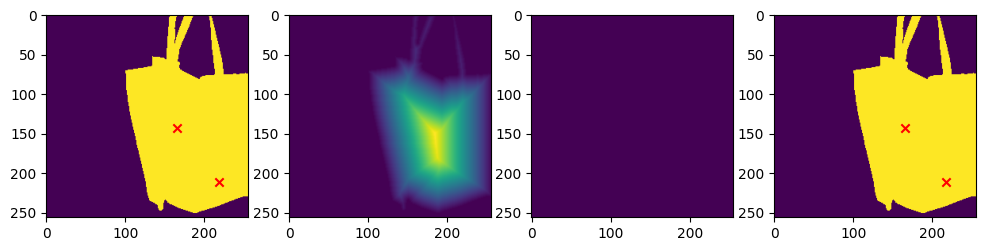

In [5]:
click_list, eroded_mask, dt = init_clicks(gt_mask)
plot_mask_clicks(gt_mask, dt, click_list)


(<Figure size 1200x600 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

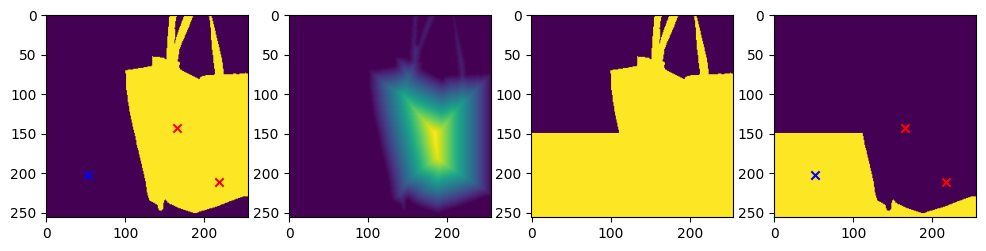

In [6]:
pred_mask = gt_mask.copy()
pred_mask[150:, :] = 1

click, click_list, not_clicked_map = predict_next_click(gt_mask, pred_mask, click_list, not_clicked_map=None)

plot_mask_clicks(gt_mask, dt, click_list, pred_mask)

In [8]:
print(to_sam_format(click_list))
print(to_sam_format(click_list, pad_size=10))

(tensor([[218, 211],
        [165, 143],
        [ 52, 202]]), tensor([1, 1, 0]))
(tensor([[218., 211.],
        [165., 143.],
        [ 52., 202.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.]]), tensor([ 1,  1,  0, -1, -1, -1, -1, -1, -1, -1]))
